# AI Hardware Architecture

**Author:** Nitin Sarangdhar  
**Affiliation:** SemiX Visiting Professor of practice | IIT Bombay  
**Date:** March 2026  

## Lab: Implementing the XOR Logic Gate from Scratch

**Description:** This notebook demonstrates the fundamental Forward and Backward pass mechanics of a (2, 2, 1) Deep Neural Network (DNN) using Stochastic Gradient Descent (SGD).

In [1]:
import numpy as np

# Training Data (4 possible combinations of 2 inputs)
# X shape: (4 samples, 2 features)
X_train = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target Labels (The 'Correct' answers for XOR)
# y shape: (4 samples, 1 output)
y_train = np.array([
    [0],
    [1],
    [1],
    [0]
])

print("Dataset defined.")
print("Inputs (X):\n", X_train)
print("Targets (y):\n", y_train)

Dataset defined.
Inputs (X):
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Targets (y):
 [[0]
 [1]
 [1]
 [0]]


Define the DNN. It has 3 layers. The input layer has 2 input neurons, the hidden layer has two neurons and the output layer has 1 neuron. In addition there is a bias term.

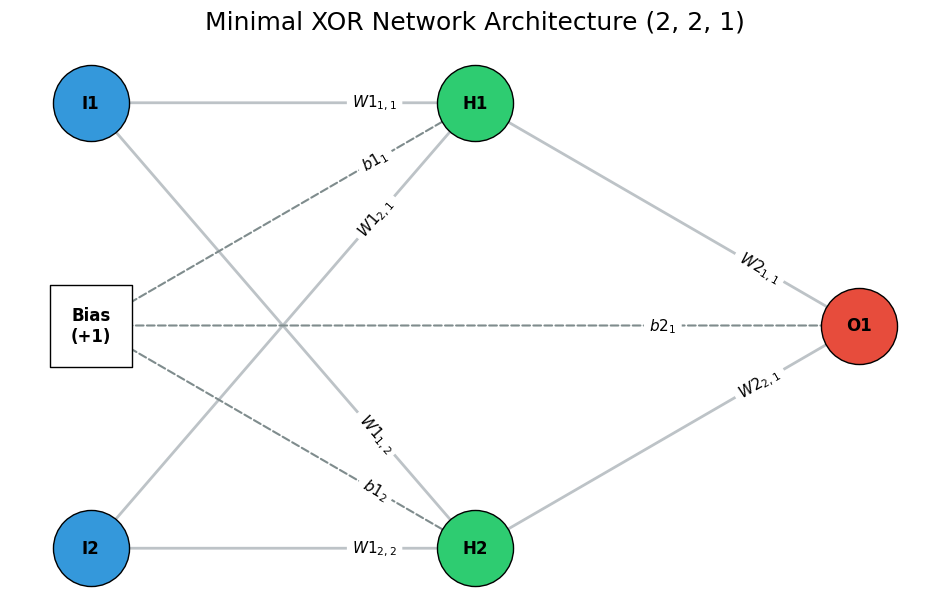

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_minimal_xor_dnn():
    # Minimal XOR Architecture: 2 Inputs, 2 Hidden, 1 Output
    N_INPUT = 2
    N_HIDDEN = 2
    N_OUTPUT = 1

    G = nx.DiGraph()
    pos = {}
    Y_SPREAD = 2.0  # Increased spread for a cleaner "minimal" look

    # --- 1. Define Node Positions ---
    # Input Layer (x=0)
    pos[0] = (0, Y_SPREAD/2)   # I1
    pos[1] = (0, -Y_SPREAD/2)  # I2
    G.add_node(0, label='I1')
    G.add_node(1, label='I2')

    # BIAS NODE: Vertically centered in the Input column (x=0, y=0)
    # Aligns perfectly with the gap between H1 and H2
    BIAS_NODE_ID = "BIAS"
    pos[BIAS_NODE_ID] = (0, 0)
    G.add_node(BIAS_NODE_ID, label='Bias\n(+1)')

    # Hidden Layer (x=1)
    # H1 at +1.0, H2 at -1.0
    for i in range(N_HIDDEN):
        node_id = N_INPUT + i
        pos[node_id] = (1, Y_SPREAD/2 if i == 0 else -Y_SPREAD/2)
        G.add_node(node_id, label=f'H{i+1}')

    # Output Layer (x=2)
    pos[4] = (2, 0) # O1
    G.add_node(4, label='O1')

    # --- 2. Define Edges and Labels (W_dest,source) ---
    edge_labels = {}
    primary_edges = []
    bias_edges = []

    # Layer 1 Weights: Input -> Hidden
    for n in range(N_INPUT):
        for m in range(N_HIDDEN):
            u, v = n, N_INPUT + m
            G.add_edge(u, v)
            primary_edges.append((u, v))
            edge_labels[(u, v)] = f'$W1_{{{n+1},{m+1}}}$'

    # Layer 2 Weights: Hidden -> Output
    for n in range(N_HIDDEN):
        for m in range(N_OUTPUT):
            u, v = N_INPUT + n, N_INPUT + N_HIDDEN + m
            G.add_edge(u, v)
            primary_edges.append((u, v))
            edge_labels[(u, v)] = f'$W2_{{{n+1},{m+1}}}$'

    # Bias Weights: Bias -> Hidden/Output
    for m in range(N_HIDDEN):
        u, v = BIAS_NODE_ID, N_INPUT + m
        G.add_edge(u, v)
        bias_edges.append((u, v))
        edge_labels[(u, v)] = f'$b1_{{{m+1}}}$'

    for m in range(N_OUTPUT):
        u, v = BIAS_NODE_ID, N_INPUT + N_HIDDEN + m
        G.add_edge(u, v)
        bias_edges.append((u, v))
        edge_labels[(u, v)] = f'$b2_{{{m+1}}}$'

    # --- 3. Rendering ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=[0, 1], node_color='#3498db', node_size=3000, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=[2, 3], node_color='#2ecc71', node_size=3000, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=[4], node_color='#e74c3c', node_size=3000, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=[BIAS_NODE_ID], node_color='white', node_shape='s', node_size=3500, edgecolors='black')

    # Labels
    nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'), font_size=12, font_weight='bold')

    # Edges
    nx.draw_networkx_edges(G, pos, edgelist=primary_edges, edge_color='#bdc3c7', width=2, arrowsize=25)
    nx.draw_networkx_edges(G, pos, edgelist=bias_edges, edge_color='#7f8c8d', style='dashed', width=1.5, arrowsize=20)

    # Edge Labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, label_pos=0.75)

    plt.title("Minimal XOR Network Architecture (2, 2, 1)", fontsize=18, pad=20)
    plt.axis('off')
    plt.show()

draw_minimal_xor_dnn()

Each neuron in the previous layer is connected to the neuron in the next layer with a weight. The bias is also connected to each neuron with a weight. Initialize the weights to random values

In [3]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# --- Layer 1: Input (2) -> Hidden (2) ---
# W1 shape: (destination_neurons, source_neurons) -> (2, 2)
W1 = np.random.randn(2, 2)
# b1 shape: (destination_neurons, 1) -> (2, 1)
b1 = np.random.randn(2, 1)

# --- Layer 2: Hidden (2) -> Output (1) ---
# W2 shape: (destination_neurons, source_neurons) -> (1, 2)
W2 = np.random.randn(1, 2)
# b2 shape: (destination_neurons, 1) -> (1, 1)
b2 = np.random.randn(1, 1)

# --- Display for the Class ---
print("-" * 40)
print("LAYER 1 INITIALIZATION (Input to Hidden)")
print("-" * 40)
print(f"Weights Matrix W1 (2x2):\n{W1}")
print(f"\nBias Vector b1 (2x1):\n{b1}")

print("\n" + "-" * 40)
print("LAYER 2 INITIALIZATION (Hidden to Output)")
print("-" * 40)
print(f"Weights Matrix W2 (1x2):\n{W2}")
print(f"\nBias Vector b2 (1x1):\n{b2}")
print("-" * 40)

----------------------------------------
LAYER 1 INITIALIZATION (Input to Hidden)
----------------------------------------
Weights Matrix W1 (2x2):
[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]

Bias Vector b1 (2x1):
[[-0.23415337]
 [-0.23413696]]

----------------------------------------
LAYER 2 INITIALIZATION (Hidden to Output)
----------------------------------------
Weights Matrix W2 (1x2):
[[1.57921282 0.76743473]]

Bias Vector b2 (1x1):
[[-0.46947439]]
----------------------------------------


Start training the network. In this example we are training the network through 1 episode. Each input is passed through the forward pass logic to calculate the predicted output. The predicted output is compared against the actual output to calculate the error. The error is used to apply a correction to the weights. The whole process is repeated until all inputs go through the same process.

In [4]:
import numpy as np

# 1. Setup Data and Network
np.random.seed(42)
X_train = np.array([[0,0], [0,1], [1,0], [1,1]])
y_train = np.array([[0], [1], [1], [0]])

# Initialize (2, 2, 1) Network
W1 = np.random.randn(2, 2)
b1 = np.random.randn(2, 1)
W2 = np.random.randn(1, 2)
b2 = np.random.randn(1, 1)

learning_rate = 0.5

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    # Derivative of sigmoid using the activation 'a'
    return a * (1 - a)

# 2. Training Loop (One Epoch of SGD)
print(f"{'='*60}")
print(f"STARTING SGD TRAINING: 1 EPOCH (4 SAMPLES)")
print(f"{'='*60}\n")

for i in range(len(X_train)):
    # --- PREPARATION ---
    # Grab one sample and reshape to column vector (2, 1)
    x = X_train[i].reshape(2, 1)
    target = y_train[i].reshape(1, 1)

    print(f"--- STAGE {i+1}: Training on Input {X_train[i]} (Target: {y_train[i][0]}) ---")

    # --- FORWARD PASS ---
    # Layer 1 (Input to Hidden)
    z1 = np.dot(W1, x) + b1
    a1 = sigmoid(z1)

    # Layer 2 (Hidden to Output)
    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    prediction = a2[0, 0]
    error = target - a2
    print(f"  [Forward] Predicted: {prediction:.4f} | Error: {error[0, 0]:.4f}")

    # --- BACKWARD PASS (The Chain Rule in action) ---

    # 1. Calculate output layer gradient (delta)
    # delta2 = error * derivative of sigmoid at output
    delta2 = error * sigmoid_derivative(a2)

    # 2. Calculate hidden layer gradient (delta)
    # delta1 = (W2_transpose * delta2) * derivative of sigmoid at hidden
    delta1 = np.dot(W2.T, delta2) * sigmoid_derivative(a1)

    # --- WEIGHT UPDATES (Nudging the parameters) ---

    # Update Layer 2
    # W2_new = W2_old + (learning_rate * delta2 * a1_transpose)
    W2_update = learning_rate * np.dot(delta2, a1.T)
    W2 += W2_update
    b2 += learning_rate * delta2

    # Update Layer 1
    # W1_new = W1_old + (learning_rate * delta1 * x_transpose)
    W1_update = learning_rate * np.dot(delta1, x.T)
    W1 += W1_update
    b1 += learning_rate * delta1

    print(f"  [Backward] Updated W2 by average: {np.mean(np.abs(W2_update)):.6f}")
    print(f"  [Backward] Updated W1 by average: {np.mean(np.abs(W1_update)):.6f}\n")

print(f"{'='*60}")
print("End of Epoch 1. Weights have been adjusted 4 times.")

STARTING SGD TRAINING: 1 EPOCH (4 SAMPLES)

--- STAGE 1: Training on Input [0 0] (Target: 0) ---
  [Forward] Predicted: 0.6381 | Error: -0.6381
  [Backward] Updated W2 by average: 0.032546
  [Backward] Updated W1 by average: 0.000000

--- STAGE 2: Training on Input [0 1] (Target: 1) ---
  [Forward] Predicted: 0.6574 | Error: 0.3426
  [Backward] Updated W2 by average: 0.022818
  [Backward] Updated W1 by average: 0.004794

--- STAGE 3: Training on Input [1 0] (Target: 1) ---
  [Forward] Predicted: 0.6967 | Error: 0.3033
  [Backward] Updated W2 by average: 0.018607
  [Backward] Updated W1 by average: 0.004551

--- STAGE 4: Training on Input [1 1] (Target: 0) ---
  [Forward] Predicted: 0.7431 | Error: -0.7431
  [Backward] Updated W2 by average: 0.050073
  [Backward] Updated W1 by average: 0.016978

End of Epoch 1. Weights have been adjusted 4 times.


The network is trained through 20000 epochs

In [5]:
epochs = 20000
learning_rate = 0.5
history = []

for epoch in range(epochs):
    epoch_loss = 0
    for i in range(len(X_train)):
        # -- SGD: One sample at a time --
        x = X_train[i].reshape(2, 1)
        target = y_train[i].reshape(1, 1)

        # Forward
        a1 = sigmoid(np.dot(W1, x) + b1)
        a2 = sigmoid(np.dot(W2, a1) + b2)

        # Backward (using the logic from the previous script)
        error = target - a2
        delta2 = error * sigmoid_derivative(a2)
        delta1 = np.dot(W2.T, delta2) * sigmoid_derivative(a1)

        # Updates
        W2 += learning_rate * np.dot(delta2, a1.T)
        b2 += learning_rate * delta2
        W1 += learning_rate * np.dot(delta1, x.T)
        b1 += learning_rate * delta1

        epoch_loss += np.mean(np.square(error))

    history.append(epoch_loss / 4)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} - Loss: {history[-1]:.6f}")

print("\nTraining Complete!")

Epoch 0 - Loss: 0.283673
Epoch 1000 - Loss: 0.143743
Epoch 2000 - Loss: 0.136506
Epoch 3000 - Loss: 0.135075
Epoch 4000 - Loss: 0.134491
Epoch 5000 - Loss: 0.134178
Epoch 6000 - Loss: 0.133983
Epoch 7000 - Loss: 0.133851
Epoch 8000 - Loss: 0.133756
Epoch 9000 - Loss: 0.133684
Epoch 10000 - Loss: 0.133628
Epoch 11000 - Loss: 0.133583
Epoch 12000 - Loss: 0.133546
Epoch 13000 - Loss: 0.133515
Epoch 14000 - Loss: 0.133489
Epoch 15000 - Loss: 0.133467
Epoch 16000 - Loss: 0.133448
Epoch 17000 - Loss: 0.133431
Epoch 18000 - Loss: 0.133416
Epoch 19000 - Loss: 0.133403

Training Complete!


Now test the network for valid output. Output 2 is wrong so the network did not get trained properly.

In [6]:
import numpy as np

# --- FINAL INFERENCE TEST ---
print(f"{'='*50}")
print("FINAL INFERENCE RESULTS (After Training)")
print(f"{'='*50}")
print(f"{'Input (X1, X2)':<18} | {'Target':<8} | {'Prediction (O1)':<15}")
print("-" * 50)

# We use the weights (W1, W2) and biases (b1, b2)
# updated from your 10,000 epoch training loop
for i in range(len(X_train)):
    # 1. Prepare the input sample
    x_input = X_train[i].reshape(2, 1)
    target_val = y_train[i][0]

    # 2. Forward Pass: Layer 1
    z1 = np.dot(W1, x_input) + b1
    a1 = sigmoid(z1)

    # 3. Forward Pass: Layer 2
    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    # 4. Final Result
    prediction = a2[0, 0]

    # Formatting the output for clarity
    input_str = f"[{X_train[i][0]}, {X_train[i][1]}]"
    print(f"{input_str:<18} | {target_val:<8} | {prediction:.6f}")

print(f"{'='*50}")

FINAL INFERENCE RESULTS (After Training)
Input (X1, X2)     | Target   | Prediction (O1)
--------------------------------------------------
[0, 0]             | 0        | 0.012473
[0, 1]             | 1        | 0.483724
[1, 0]             | 1        | 0.986726
[1, 1]             | 0        | 0.484205


We retrain the network by changing the hyperparameter learning rate = 1.0 and train the network for 20000 epochs

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Setup Data & Helper Functions ---
X_train = np.array([[0,0], [0,1], [1,0], [1,1]])
y_train = np.array([[0], [1], [1], [0]])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- 2. Initialize Network (2, 2, 1) ---
np.random.seed(7)
W1 = np.random.randn(2, 2)
b1 = np.random.randn(2, 1)
W2 = np.random.randn(1, 2)
b2 = np.random.randn(1, 1)

learning_rate = 1.0
epochs = 20000
history = []

print(f"Starting Training for {epochs} epochs...")

# --- 3. The Training Loop (SGD) ---
for epoch in range(epochs):
    epoch_loss = 0  # Reset loss at the start of each epoch

    for i in range(len(X_train)):
        # Grab one sample (Stochastic)
        x = X_train[i].reshape(2, 1)
        target = y_train[i].reshape(1, 1)

        # FORWARD PASS
        # Layer 1 (Input to Hidden)
        z1 = np.dot(W1, x) + b1
        a1 = sigmoid(z1)

        # Layer 2 (Hidden to Output)
        z2 = np.dot(W2, a1) + b2
        a2 = sigmoid(z2)

        # CALCULATE ERROR (MSE contribution)
        error = target - a2
        epoch_loss += np.mean(np.square(error))

        # BACKWARD PASS (Blame Assignment)
        # Output Gradient
        delta2 = error * (a2 * (1 - a2))
        # Hidden Gradient
        delta1 = np.dot(W2.T, delta2) * (a1 * (1 - a1))

        # WEIGHT UPDATES (The Nudge)
        W2 += learning_rate * np.dot(delta2, a1.T)
        b2 += learning_rate * delta2
        W1 += learning_rate * np.dot(delta1, x.T)
        b1 += learning_rate * delta1

    # Record average loss for this epoch
    average_loss = epoch_loss / 4
    history.append(average_loss)

    # Print progress every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Mean Squared Error: {average_loss:.6f}")

print("\nTraining complete!")

# --- 4. Final Inference Test ---
print("\n" + "="*45)
print("FINAL INFERENCE RESULTS")
print("="*45)
for i in range(len(X_train)):
    x_test = X_train[i].reshape(2, 1)
    # Forward Pass Only
    a1 = sigmoid(np.dot(W1, x_test) + b1)
    a2 = sigmoid(np.dot(W2, a1) + b2)
    print(f"Input: {X_train[i]} | Target: {y_train[i][0]} | Prediction: {a2[0,0]:.4f}")

Starting Training for 20000 epochs...
Epoch     0 | Mean Squared Error: 0.282076
Epoch  1000 | Mean Squared Error: 0.002604
Epoch  2000 | Mean Squared Error: 0.000890
Epoch  3000 | Mean Squared Error: 0.000527
Epoch  4000 | Mean Squared Error: 0.000372
Epoch  5000 | Mean Squared Error: 0.000287
Epoch  6000 | Mean Squared Error: 0.000233
Epoch  7000 | Mean Squared Error: 0.000196
Epoch  8000 | Mean Squared Error: 0.000169
Epoch  9000 | Mean Squared Error: 0.000149
Epoch 10000 | Mean Squared Error: 0.000132
Epoch 11000 | Mean Squared Error: 0.000119
Epoch 12000 | Mean Squared Error: 0.000109
Epoch 13000 | Mean Squared Error: 0.000100
Epoch 14000 | Mean Squared Error: 0.000092
Epoch 15000 | Mean Squared Error: 0.000086
Epoch 16000 | Mean Squared Error: 0.000080
Epoch 17000 | Mean Squared Error: 0.000075
Epoch 18000 | Mean Squared Error: 0.000071
Epoch 19000 | Mean Squared Error: 0.000067

Training complete!

FINAL INFERENCE RESULTS
Input: [0 0] | Target: 0 | Prediction: 0.0079
Input: [0 1

We test the network again for all inputs. The output looks correct so we have a fully trained DNN that correctly implements the XOR gate

In [8]:
import numpy as np

# --- FINAL INFERENCE TEST ---
print(f"{'='*50}")
print("FINAL INFERENCE RESULTS (After Training)")
print(f"{'='*50}")
print(f"{'Input (X1, X2)':<18} | {'Target':<8} | {'Prediction (O1)':<15}")
print("-" * 50)

# We use the weights (W1, W2) and biases (b1, b2)
# updated from your 10,000 epoch training loop
for i in range(len(X_train)):
    # 1. Prepare the input sample
    x_input = X_train[i].reshape(2, 1)
    target_val = y_train[i][0]

    # 2. Forward Pass: Layer 1
    z1 = np.dot(W1, x_input) + b1
    a1 = sigmoid(z1)

    # 3. Forward Pass: Layer 2
    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    # 4. Final Result
    prediction = a2[0, 0]

    # Formatting the output for clarity
    input_str = f"[{X_train[i][0]}, {X_train[i][1]}]"
    print(f"{input_str:<18} | {target_val:<8} | {prediction:.6f}")

print(f"{'='*50}")

FINAL INFERENCE RESULTS (After Training)
Input (X1, X2)     | Target   | Prediction (O1)
--------------------------------------------------
[0, 0]             | 0        | 0.007945
[0, 1]             | 1        | 0.990898
[1, 0]             | 1        | 0.992513
[1, 1]             | 0        | 0.007108


We retrain the network using Batch Gradient Descent. That is we update the weight only once after cycling through entire dataset

In [9]:
import numpy as np

# --- 1. Data Setup (Transpose for Matrix Math) ---
# X_train is (4, 2), we want (2, 4) so each column is one XOR sample
X_batch = X_train.T
y_batch = y_train.T # (1, 4)

# --- 2. Re-Initialize ---
np.random.seed(7)
W1 = np.random.randn(2, 2)
b1 = np.random.randn(2, 1)
W2 = np.random.randn(1, 2)
b2 = np.random.randn(1, 1)

learning_rate = 1.0
epochs = 40000 # Batch often needs more epochs because updates are less frequent
history = []

# --- 3. Batch Training Loop ---
for epoch in range(epochs):
    # FORWARD PASS (All 4 samples at once)
    z1 = np.dot(W1, X_batch) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    # ERROR CALCULATION
    error = y_batch - a2
    loss = np.mean(np.square(error))
    history.append(loss)

    # BACKWARD PASS (Batch Gradients)
    delta2 = error * (a2 * (1 - a2))
    # Note: We divide by 4 (the batch size) to get the average gradient
    delta1 = np.dot(W2.T, delta2) * (a1 * (1 - a1))

    # WEIGHT UPDATES (One update per epoch)
    # Using dot product here effectively sums the gradients across the batch
    W2 += (learning_rate / 4) * np.dot(delta2, a1.T)
    b2 += (learning_rate / 4) * np.sum(delta2, axis=1, keepdims=True)

    W1 += (learning_rate / 4) * np.dot(delta1, X_batch.T)
    b1 += (learning_rate / 4) * np.sum(delta1, axis=1, keepdims=True)

    if epoch % 5000 == 0:
        print(f"Epoch {epoch:5d} | Batch Loss: {loss:.6f}")

print("\nBatch Training Complete!")

Epoch     0 | Batch Loss: 0.250642
Epoch  5000 | Batch Loss: 0.001927
Epoch 10000 | Batch Loss: 0.000684
Epoch 15000 | Batch Loss: 0.000409
Epoch 20000 | Batch Loss: 0.000291
Epoch 25000 | Batch Loss: 0.000225
Epoch 30000 | Batch Loss: 0.000183
Epoch 35000 | Batch Loss: 0.000154

Batch Training Complete!


In [10]:
import numpy as np

# --- 1. SETUP: Input Image with a Vertical Bar ---
image = np.zeros((10, 10))
image[:, 4:6] = 10

# Define Two Kernels
v_kernel = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]) # Vertical Edge
h_kernel = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]) # Horizontal Edge

# --- 2. CONVOLUTION LAYER ---
def conv2d(img, k):
    h, w = img.shape
    kh, kw = k.shape
    res = np.zeros((h-kh+1, w-kw+1))
    for r in range(h-kh+1):
        for c in range(w-kw+1):
            res[r, c] = np.sum(img[r:r+kh, c:c+kw] * k)
    return res

v_feature_map = conv2d(image, v_kernel)
h_feature_map = conv2d(image, h_kernel)

# --- 3. MAX POOLING (2x2 Stride 2) ---
def max_pooling(feature_map, size=2):
    h, w = feature_map.shape
    res = np.zeros((h // size, w // size))
    for r in range(0, h, size):
        for c in range(0, w, size):
            # Take the maximum value in the 2x2 window
            window = feature_map[r:r+size, c:c+size]
            res[r // size, c // size] = np.max(window)
    return res

v_pool = max_pooling(v_feature_map)
h_pool = max_pooling(h_feature_map)

# --- 4. PRINTING THE HARDWARE PIPELINE ---
print("="*60)
print("THE CNN PIPELINE: VERTICAL vs HORIZONTAL")
print("="*60)

print("\n[STEP 1] 8x8 VERTICAL FEATURE MAP (After Conv):")
for row in v_feature_map:
    print(" ".join(f"{int(val):3d}" for val in row))

print("\n[STEP 2] 4x4 MAX POOLED MAP (Data Compression):")
for row in v_pool:
    print(" ".join(f"{int(val):3d}" for val in row))

# --- 5. SIMPLE CLASSIFIER LOGIC ---
v_score = np.sum(v_pool)
h_score = np.sum(h_pool)

print("\n" + "="*60)
print("FINAL CLASSIFICATION")
print("="*60)
print(f"Vertical Signal Strength:   {v_score}")
print(f"Horizontal Signal Strength: {h_score}")

if v_score > h_score and v_score > 0:
    print("\nRESULT: VERTICAL EDGE DETECTED!")
elif h_score > v_score and h_score > 0:
    print("\nRESULT: HORIZONTAL EDGE DETECTED!")
else:
    print("\nRESULT: NO CLEAR EDGE DETECTED")

THE CNN PIPELINE: VERTICAL vs HORIZONTAL

[STEP 1] 8x8 VERTICAL FEATURE MAP (After Conv):
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0
  0   0  30  30 -30 -30   0   0

[STEP 2] 4x4 MAX POOLED MAP (Data Compression):
  0  30 -30   0
  0  30 -30   0
  0  30 -30   0
  0  30 -30   0

FINAL CLASSIFICATION
Vertical Signal Strength:   0.0
Horizontal Signal Strength: 0.0

RESULT: NO CLEAR EDGE DETECTED


Test if the DNN is trained correctly. It is

In [11]:
import numpy as np

# --- FINAL INFERENCE TEST ---
print(f"{'='*50}")
print("FINAL INFERENCE RESULTS (After Training)")
print(f"{'='*50}")
print(f"{'Input (X1, X2)':<18} | {'Target':<8} | {'Prediction (O1)':<15}")
print("-" * 50)

# We use the weights (W1, W2) and biases (b1, b2)
# updated from your 10,000 epoch training loop
for i in range(len(X_train)):
    # 1. Prepare the input sample
    x_input = X_train[i].reshape(2, 1)
    target_val = y_train[i][0]

    # 2. Forward Pass: Layer 1
    z1 = np.dot(W1, x_input) + b1
    a1 = sigmoid(z1)

    # 3. Forward Pass: Layer 2
    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    # 4. Final Result
    prediction = a2[0, 0]

    # Formatting the output for clarity
    input_str = f"[{X_train[i][0]}, {X_train[i][1]}]"
    print(f"{input_str:<18} | {target_val:<8} | {prediction:.6f}")

print(f"{'='*50}")

FINAL INFERENCE RESULTS (After Training)
Input (X1, X2)     | Target   | Prediction (O1)
--------------------------------------------------
[0, 0]             | 0        | 0.011560
[0, 1]             | 1        | 0.986805
[1, 0]             | 1        | 0.989128
[1, 1]             | 0        | 0.010298
